In [2]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import transforms
from torchvision import datasets
from transformers import AutoImageProcessor
from transformers import CvtForImageClassification
from transformers import TrainingArguments, Trainer

In [3]:
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.targets):
        target_idx[int(label)].append(idx)

    indices = list(chain.from_iterable([target_idx[idx][:max_len] for idx in range(len(classes))]))
    return Subset(dataset, indices)

def model_init(classes, class_to_idx):
    return CvtForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/cvt-21",
        num_labels=len(classes),
        id2label = {idx: label for label, idx in class_to_idx.items()},
        label2id = class_to_idx,
        ignore_mismatched_sizes = True
    )

def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {'pixel_values': pixel_values, 'labels': labels}

def compute_metrics(eval_pred):
    metric = evaluate.load('f1')
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(predictions=predictions, references=labels, average='macro')
    return macro_f1

In [4]:
train_dataset = datasets.FashionMNIST(root= './datasets', download = True, train = True)
test_dataset = datasets.FashionMNIST(root= './datasets', download = True, train = False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(dataset = train_dataset, 
                                      classes = train_dataset.classes, 
                                      max_len = 1000)

subset_test_dataset = subset_sampler(dataset = test_dataset,
                                      classes = test_dataset.classes,
                                      max_len = 100)

In [6]:
image_processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path="microsoft/cvt-21")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size = (image_processor.size['shortest_edge'],
                                 image_processor.size['shortest_edge'])),
    transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
    transforms.Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
])

args = TrainingArguments(
    output_dir = './model/Cvt-FashionMNIST',
    save_strategy = 'epoch',
    evaluation_strategy = 'epoch',
    learning_rate = 1e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.001,
    load_best_model_at_end = True,
    metric_for_best_model = 'f1',
    logging_dir = 'logs',
    logging_steps = 125,
    remove_unused_columns = False,
    seed = 42)

trainer = Trainer(model_init = lambda x: model_init(classes, class_to_idx),
                  args = args, train_dataset = subset_train_dataset,
                  eval_dataset = subset_test_dataset,
                  data_collator = lambda x: collator(x, transform),
                  compute_metrics = compute_metrics,
                  tokenizer = image_processor)

trainer.train()

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\accelerate\accelerator.py:457: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None)
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- clas

{'loss': 1.5549, 'learning_rate': 9.333333333333334e-06, 'epoch': 0.2}


 13%|█▎        | 250/1875 [01:04<07:08,  3.79it/s]

{'loss': 0.9598, 'learning_rate': 8.666666666666668e-06, 'epoch': 0.4}


 20%|██        | 375/1875 [01:37<06:37,  3.77it/s]

...

                                                   
100%|██████████| 1875/1875 [08:36<00:00,  4.00it/s]

{'eval_loss': 0.24646052718162537, 'eval_f1': 0.9220607558355732, 'eval_runtime': 8.0281, 'eval_samples_per_second': 124.562, 'eval_steps_per_second': 7.847, 'epoch': 3.0}


100%|██████████| 1875/1875 [08:36<00:00,  3.63it/s]

{'train_runtime': 516.925, 'train_samples_per_second': 58.035, 'train_steps_per_second': 3.627, 'train_loss': 0.7828519897460937, 'epoch': 3.0}


TrainOutput(global_step=1875, training_loss=0.7828519897460937, metrics={'train_runtime': 516.925, 'train_samples_per_second': 58.035, 'train_steps_per_second': 3.627, 'train_loss': 0.7828519897460937, 'epoch': 3.0})

100%|██████████| 63/63 [00:07<00:00,  8.02it/s]


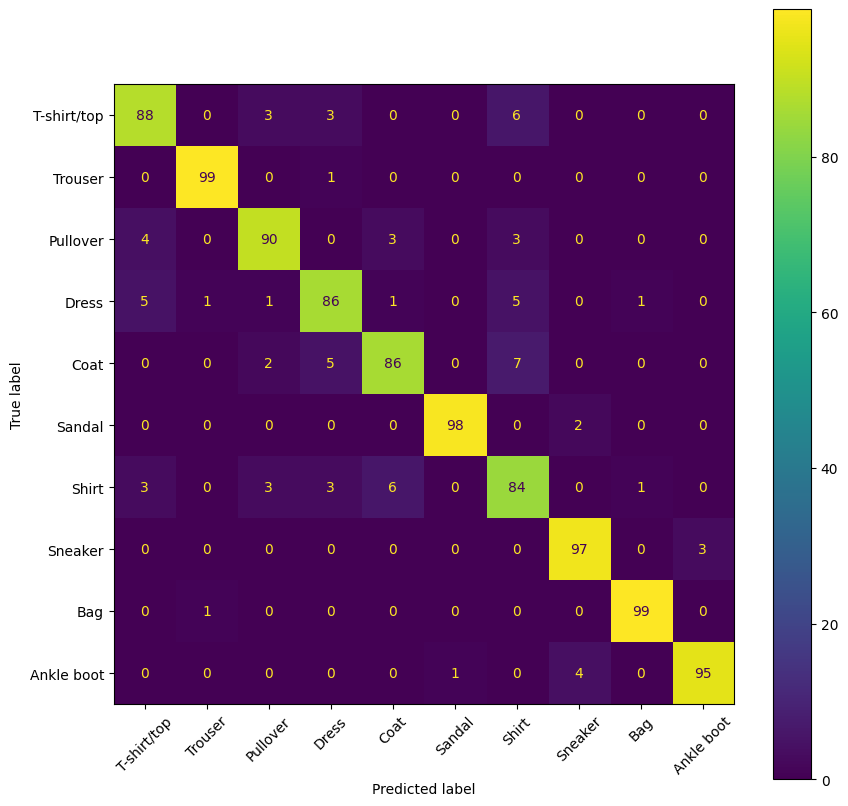

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

outputs = trainer.predict(subset_test_dataset)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)
labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = labels)

_, ax = plt.subplots(figsize = (10,10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()
